# SmCo Hexagonal Permanent-Magnet Array (Radia MMM/MSC)

Hexagonal close-packed array of cylindrical **Samarium-Cobalt (SmCo)** permanent
magnets on a meshed soft-iron base plate, solved with Radia's collocation
demagnetization (MMM/MSC). Self-contained: this notebook builds the geometry,
solves, probes the field, writes `smco_results.json`, and renders the midplane
`Bz` map (also saved as `smco_bz_map.png`).

Ported from the lab Mathematica notebook `2023_10_01` (SmCo array).

**Two corrections made when promoting this example from `examples/` to `docs/`:**

1. **Element API** -- `ObjHexahedron` / `ObjWedge` now require a magnetization
   argument; the inner ring of the meshed disk is a 6-vertex **wedge** and must
   use `ObjWedge` (the old script called `ObjHexahedron` for every ring).
2. **Magnetization units** -- Radia uses **M in A/m**, not Tesla
   (`M = Br / mu_0`). The old script passed `mag_M=[0,0,1]` intending "1 T",
   which Radia read as 1 A/m (essentially zero field). Here a typical SmCo
   remanence `Br = 1.05 T` gives `M = Br/mu_0 ~ 8.36e5 A/m`.

In [1]:
import json
import time
import numpy as np
import radia as rad

mm = 1e-3
MU0 = 4e-7 * np.pi
BR_SMCO = 1.05            # SmCo (Sm2Co17) remanence (T), typical 0.9-1.15 T
M_SMCO = BR_SMCO / MU0    # magnetization in A/m  (Radia uses A/m: M = Br/mu_0)
print(f"SmCo Br = {BR_SMCO} T  ->  M = {M_SMCO:.0f} A/m")

SmCo Br = 1.05 T  ->  M = 835563 A/m


## Meshed soft-iron base plate

The base plate is a meshed circular disk (mu_r = 1000). The innermost radial ring
degenerates to triangular cross-section, so those cells are **wedges**
(`ObjWedge`, 6 vertices); the outer annular sectors are **hexahedra**
(`ObjHexahedron`, 8 vertices). All base-plate elements start at M = 0 and pick up
induced magnetization from `Solve`.

In [2]:
def create_meshed_disk(R, H, n_radial, n_angular, n_z=1, x0=0, y0=0, z0=0):
    """Meshed iron disk: wedge core ring + hexahedral annular sectors (M=0)."""
    elems = []
    r_vals = np.linspace(0, R, n_radial + 1)
    theta_vals = np.linspace(0, 2 * np.pi, n_angular + 1)
    z_vals = np.linspace(z0 - H / 2, z0 + H / 2, n_z + 1)
    zero = [0.0, 0.0, 0.0]
    for k in range(n_z):
        zb, zt = float(z_vals[k]), float(z_vals[k + 1])
        for i in range(n_radial):
            ri, ro = float(r_vals[i]), float(r_vals[i + 1])
            for j in range(n_angular):
                t1, t2 = float(theta_vals[j]), float(theta_vals[j + 1])
                if i == 0:  # core ring -> wedge (triangular cross-section)
                    pts = [
                        [x0, y0, zb],
                        [ro*np.cos(t1)+x0, ro*np.sin(t1)+y0, zb],
                        [ro*np.cos(t2)+x0, ro*np.sin(t2)+y0, zb],
                        [x0, y0, zt],
                        [ro*np.cos(t1)+x0, ro*np.sin(t1)+y0, zt],
                        [ro*np.cos(t2)+x0, ro*np.sin(t2)+y0, zt],
                    ]
                    elems.append(rad.ObjWedge([[float(c) for c in p] for p in pts], zero))
                else:       # outer ring -> hexahedron (annular sector)
                    pts = [
                        [ri*np.cos(t1)+x0, ri*np.sin(t1)+y0, zb],
                        [ro*np.cos(t1)+x0, ro*np.sin(t1)+y0, zb],
                        [ro*np.cos(t2)+x0, ro*np.sin(t2)+y0, zb],
                        [ri*np.cos(t2)+x0, ri*np.sin(t2)+y0, zb],
                        [ri*np.cos(t1)+x0, ri*np.sin(t1)+y0, zt],
                        [ro*np.cos(t1)+x0, ro*np.sin(t1)+y0, zt],
                        [ro*np.cos(t2)+x0, ro*np.sin(t2)+y0, zt],
                        [ri*np.cos(t2)+x0, ri*np.sin(t2)+y0, zt],
                    ]
                    elems.append(rad.ObjHexahedron([[float(c) for c in p] for p in pts], zero))
    return rad.ObjCnt(elems)

## Hexagonal magnet array

Cylindrical magnets (`ObjCylMag`, 16-sided prism) on a hexagonal grid: every other
row offset by half the spacing, y-pitch `spacing * sqrt(3)/2`. Only magnets whose
centre falls inside `array_radius` are kept.

In [3]:
def build(mag_radius=5*mm, mag_height=10*mm, mag_M=(0, 0, M_SMCO),
          spacing=10*mm, array_radius=60*mm, base_plate_height=20*mm):
    base = create_meshed_disk(array_radius, base_plate_height, 6, 24, 2)
    rad.MatApl(base, rad.MatLin(1000))          # soft iron, mu_r = 1000
    objs, count = [base], 0
    for nx in range(-20, 21):
        for ny in range(-20, 21):
            x = nx*spacing + (ny % 2)*spacing/2
            y = ny*spacing*np.sqrt(3)/2
            z = base_plate_height/2 + mag_height/2
            if x*x + y*y < array_radius*array_radius:
                objs.append(rad.ObjCylMag([x, y, z], mag_radius, mag_height,
                                          16, 'z', list(mag_M)))
                count += 1
    return rad.ObjCnt(objs), count

## Solve and probe

The soft-iron base plate makes this a coupled problem, so `Solve` is required
(LU; the iron picks up induced magnetization while the SmCo magnets stay fixed).

In [4]:
rad.UtiDelAll()
t0 = time.time(); geom, n = build(); t_build = time.time() - t0
t0 = time.time(); res = rad.Solve(geom, 1e-4, 1000, 0); t_solve = time.time() - t0
iters = res[-1] if isinstance(res, (list, tuple)) else res
print(f"magnets={n}  iron_elems={6*24*2}  iters={iters}  "
      f"t_build={t_build:.2f}s  t_solve={t_solve:.2f}s")

probes = [[0, 0, 0.02], [0, 0, 0.05], [0.03, 0, 0.02]]
probe_out = []
print(f"\n{'position (m)':<24}{'Bx(mT)':>12}{'By(mT)':>12}{'Bz(mT)':>12}{'|B|(mT)':>12}")
for p in probes:
    B = rad.Fld(geom, 'b', p)
    bx, by, bz = (b*1e3 for b in B)
    bmag = float(np.linalg.norm(B)*1e3)
    probe_out.append({"pos_m": p, "B_mT": [bx, by, bz], "Bmag_mT": bmag})
    print(f"({p[0]:.3f}, {p[1]:.3f}, {p[2]:.3f}){'':<6}"
          f"{bx:>12.4f}{by:>12.4f}{bz:>12.4f}{bmag:>12.4f}")

magnets=125  iron_elems=288  iters=1.0  t_build=0.02s  t_solve=3.25s

position (m)                  Bx(mT)      By(mT)      Bz(mT)     |B|(mT)
(0.000, 0.000, 0.020)           -0.0086     -0.0000    177.6001    177.6001
(0.000, 0.000, 0.050)           -0.0000     -0.0000     68.4230     68.4230
(0.030, 0.000, 0.020)           25.1828     -0.0000    201.3146    202.8836


## Midplane Bz map and persisted results

`Bz` on a 41x41 grid 5 mm above the magnet tops (z = 25 mm). The hexagonal ripple
of individual magnet poles is visible. Results are written to `smco_results.json`
(committed alongside this notebook, per the Data Persistence Policy) and the figure
saved as `smco_bz_map.png`.

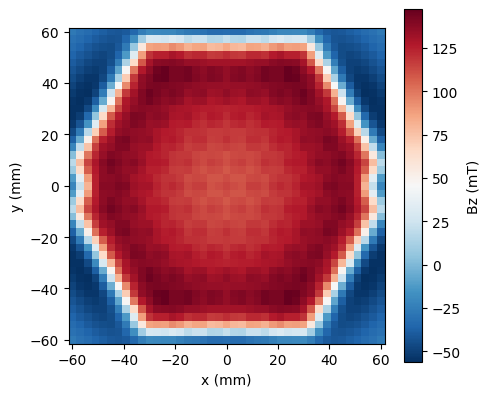

Bz at z=25 mm: -56.5 .. 147.5 mT
wrote smco_results.json


In [5]:
import matplotlib.pyplot as plt

xs = np.linspace(-0.06, 0.06, 41)
ys = np.linspace(-0.06, 0.06, 41)
zmap = 0.025
Bz = np.zeros((len(ys), len(xs)))
for iy, yv in enumerate(ys):
    Bz[iy, :] = np.array(rad.Fld(geom, 'bz',
                         [[float(xv), float(yv), zmap] for xv in xs]))*1e3

fig, ax = plt.subplots(figsize=(5.0, 4.2))
pc = ax.pcolormesh(xs*1e3, ys*1e3, Bz, shading='auto', cmap='RdBu_r')
ax.set_aspect('equal'); ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
fig.colorbar(pc, ax=ax, label='Bz (mT)')
fig.tight_layout(); fig.savefig('smco_bz_map.png', dpi=150)
plt.show()
print(f"Bz at z={zmap*1e3:.0f} mm: {Bz.min():.1f} .. {Bz.max():.1f} mT")

results = {
    "num_magnets": n, "Br_T": BR_SMCO, "M_Apm": M_SMCO,
    "n_iron_elements": 6*24*2, "solver_iterations": iters,
    "t_build_s": round(t_build, 3), "t_solve_s": round(t_solve, 3),
    "probes": probe_out,
    "map": {"x_m": xs.tolist(), "y_m": ys.tolist(), "z_m": zmap,
            "Bz_mT": Bz.tolist()},
}
with open("smco_results.json", "w") as f:
    json.dump(results, f, indent=2)
rad.UtiDelAll()
print("wrote smco_results.json")

## Notes

**SmCo (Sm2Co17 / SmCo5)** -- rare-earth permanent magnet. Remanence ~0.9-1.15 T,
very high coercivity (~700-900 kA/m), excellent temperature stability
(250-350 C). Modelled here as fixed magnetization (no demagnetization curve), at
room temperature.

**Method** -- the magnets are fixed-M sources; the soft-iron plate (`MatLin(1000)`)
is the only unknown, solved by collocation demagnetization (Radia MMM/MSC, LU).
Field uses Radia's exact open-boundary analytic kernel -- no air mesh, no PML.

**Units** -- everything in meters / A/m / Tesla (Radia convention). Magnetization
of a permanent magnet is `M = Br / mu_0` in A/m.